# GLP-1 WeightLoss Pulse: Exploratory Data Analysis

This notebook covers Phase 1 of the project: Environment Setup & Data Exploration (EDA).

## Objectives:
1. Load all 8 CSV files.
2. Inspect data structure and identify missing values.
3. Perform basic data cleaning (datetime conversion, missing value handling).
4. Conduct preliminary analysis for the dashboard modules.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# Set display options
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

## 1. Load Data

In [2]:
dataset_dir = 'Dataset'
files = [
    'adverse_events.csv',
    'adverse_events_summary.csv',
    'clinical_trials.csv',
    'data_dictionary.csv',
    'drugs_overview.csv',
    'search_trends.csv',
    'stock_prices.csv',
    'wikipedia_summaries.csv'
]

data = {}
for file in files:
    name = file.split('.')[0]
    data[name] = pd.read_csv(os.path.join(dataset_dir, file))
    print(f"Loaded {file}: {data[name].shape}")

Loaded adverse_events.csv: (149209, 16)
Loaded adverse_events_summary.csv: (11093, 8)
Loaded clinical_trials.csv: (1953, 11)
Loaded data_dictionary.csv: (50, 4)
Loaded drugs_overview.csv: (10, 7)
Loaded search_trends.csv: (3500, 4)
Loaded stock_prices.csv: (4680, 9)
Loaded wikipedia_summaries.csv: (9, 4)


## 2. Data Cleaning

### 2.1 Convert Dates

In [3]:
# Adverse Events
data['adverse_events']['receive_date'] = pd.to_datetime(data['adverse_events']['receive_date'])

# Clinical Trials
data['clinical_trials']['start_date'] = pd.to_datetime(data['clinical_trials']['start_date'])
data['clinical_trials']['completion_date'] = pd.to_datetime(data['clinical_trials']['completion_date'])

# Search Trends
data['search_trends']['date'] = pd.to_datetime(data['search_trends']['date'])

# Stock Prices
data['stock_prices']['date'] = pd.to_datetime(data['stock_prices']['date'])

print("Date conversions complete.")

Date conversions complete.


### 2.2 Handle Missing Values

In [4]:
# For Adverse Events, let's look at the null counts again
print(data['adverse_events'].isnull().sum())

# We will keep patient_age for distribution plots but note the missingness.
# For patient_weight_kg, we might want to fill with median if needed for specific analysis, 
# but for now we'll just be aware of it.

safetyreportid                      0
generic_name                        0
brand_queried                       0
receive_date                        0
country                             0
serious                             0
seriousness_death                   0
seriousness_lifethreatening         0
seriousness_hospitalization         0
seriousness_disabling               0
patient_age                     54817
patient_age_unit                    0
patient_sex                         0
patient_weight_kg              104493
reaction                            0
reaction_outcome                    0
dtype: int64


## 3. Preliminary Analysis

### 3.1 Top Adverse Reactions

C:\Users\Asus\AppData\Local\Temp\ipykernel_23692\1426575465.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_reactions.values, y=top_reactions.index, palette='viridis')


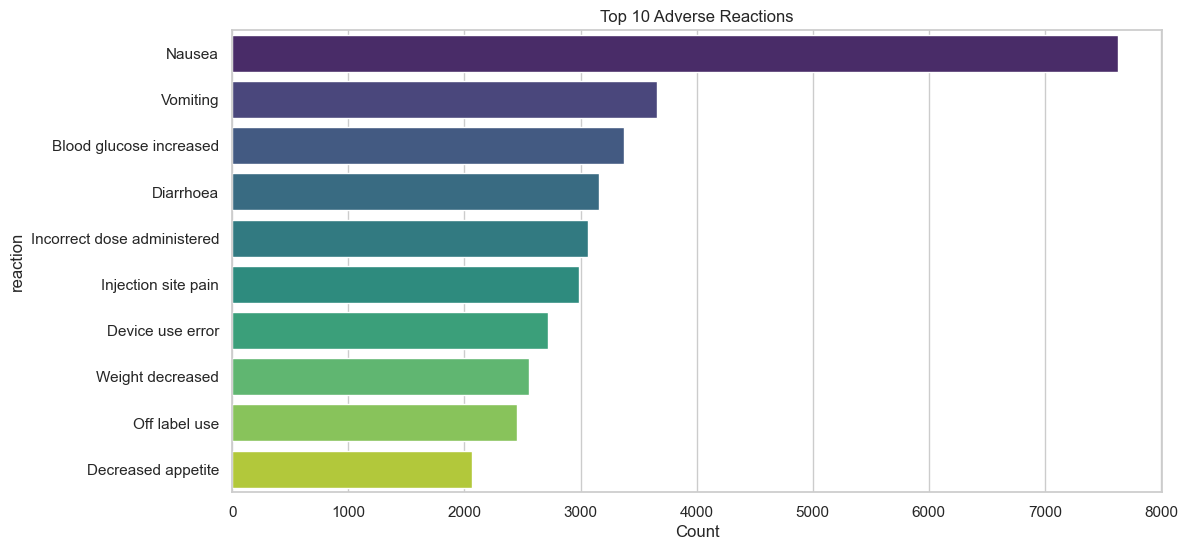

In [5]:
top_reactions = data['adverse_events']['reaction'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_reactions.values, y=top_reactions.index, palette='viridis')
plt.title('Top 10 Adverse Reactions')
plt.xlabel('Count')
plt.show()

### 3.2 Market Trends vs Search Interest

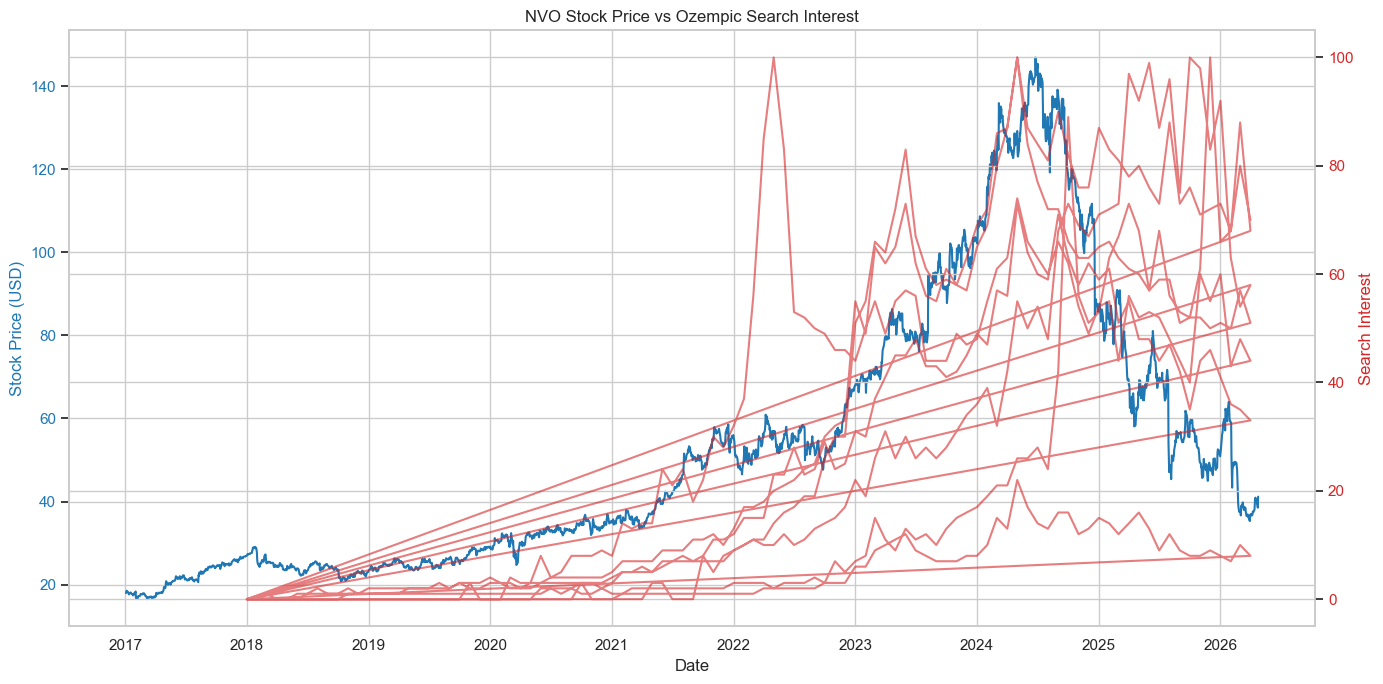

In [6]:
# Combine stock prices and search trends for a specific drug like Ozempic
ozempic_search = data['search_trends'][data['search_trends']['term'] == 'Ozempic']
nvo_stock = data['stock_prices'][data['stock_prices']['ticker'] == 'NVO']

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.set_xlabel('Date')
ax1.set_ylabel('Stock Price (USD)', color='tab:blue')
ax1.plot(nvo_stock['date'], nvo_stock['close'], color='tab:blue', label='NVO Stock Price')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Search Interest', color='tab:red')
ax2.plot(ozempic_search['date'], ozempic_search['search_interest'], color='tab:red', label='Ozempic Search Trend', alpha=0.6)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('NVO Stock Price vs Ozempic Search Interest')
fig.tight_layout()
plt.show()